# Microproyecto 2: clasificación de textos según los Objetivos de Desarrollo Sostenible

**Universidad:** Universidad de Los Andes

**Programa:** Maestría en Inteligencia Artificial Aplicada 

**Asignatura:** Machine Learning No Supervisado   

**Periodo:** 2026

**Estudiantes:** Oscar Ferney Gallo - Andrés Felipe Becerra Puerto 


## 1. Presentación del proyecto

### 1.1. Objetivo

Desarrollar una solución basada en procesamiento de lenguaje natural y machine learning que facilite la identificación de relaciones semánticas entre textos en español y los Objetivos de Desarrollo Sostenible, mediante una representación TF-IDF, un modelo de tópicos LSA y un modelo de clasificación multiclase.

### 1.2. Metodología propuesta:

El proyecto seguirá una secuencia que mantiene separado el conjunto de prueba hasta la evaluación final:

1. **Comprensión de los datos:** revisión de variables, etiquetas y calidad.
2. **Exploración:** distribución de clases, longitud y contenido de los textos.
3. **División de los datos:** entrenamiento y prueba mediante muestreo estratificado.
4. **Representación:** limpieza y ponderación TF-IDF dentro de un pipeline.
5. **Análisis no supervisado:** reducción mediante TruncatedSVD e interpretación de tópicos LSA.
6. **Clasificación:** ajuste del modelo y búsqueda de hiperparámetros usando solamente entrenamiento.
7. **Evaluación:** métricas multiclase, matriz de confusión y revisión de textos de prueba.


## 2. Preparación del entorno

### 2.1. Importación de librerías

Se importan herramientas para manipular datos, construir expresiones regulares y elaborar las visualizaciones exploratorias. También se fija una semilla para que los procedimientos aleatorios posteriores puedan reproducirse.


In [135]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from scipy.stats import loguniform, randint, uniform
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import nltk
import textwrap
import joblib

#Con la intención de tener reproducibilidad se deja el random state como variable global
RANDOM_STATE = 42

### 2.2. Nombres de los ODS

Para efectos de interpretación en el desarrollo del microproyecto, se define un diccionario con el número y nombre de cada ODS, permitiendo que las tablas y gráficas sean más fáciles de interpretar que una presentación basada solo en números.

In [30]:
nombres_ods = {
    1: "Fin de la pobreza",
    2: "Hambre cero",
    3: "Salud y bienestar",
    4: "Educación de calidad",
    5: "Igualdad de género",
    6: "Agua limpia y saneamiento",
    7: "Energía asequible y no contaminante",
    8: "Trabajo decente y crecimiento económico",
    9: "Industria, innovación e infraestructura",
    10: "Reducción de las desigualdades",
    11: "Ciudades y comunidades sostenibles",
    12: "Producción y consumo responsables",
    13: "Acción por el clima",
    14: "Vida submarina",
    15: "Vida de ecosistemas terrestres",
    16: "Paz, justicia e instituciones sólidas",
    17: "Alianzas para lograr los objetivos",
}

nombres_ods


{1: 'Fin de la pobreza',
 2: 'Hambre cero',
 3: 'Salud y bienestar',
 4: 'Educación de calidad',
 5: 'Igualdad de género',
 6: 'Agua limpia y saneamiento',
 7: 'Energía asequible y no contaminante',
 8: 'Trabajo decente y crecimiento económico',
 9: 'Industria, innovación e infraestructura',
 10: 'Reducción de las desigualdades',
 11: 'Ciudades y comunidades sostenibles',
 12: 'Producción y consumo responsables',
 13: 'Acción por el clima',
 14: 'Vida submarina',
 15: 'Vida de ecosistemas terrestres',
 16: 'Paz, justicia e instituciones sólidas',
 17: 'Alianzas para lograr los objetivos'}

## 3. Carga y comprensión de los datos

### 3.1. Carga del conjunto de datos

In [31]:
ruta = Path("Datos_textosODS.xlsx")
datos = pd.read_excel(ruta)

print(f"Número de filas: {datos.shape[0]:,}")
print(f"Número de columnas: {datos.shape[1]}")
print(f"Nombre de columnas: {datos.columns}")


Número de filas: 9,656
Número de columnas: 2
Nombre de columnas: Index(['textos', 'ODS'], dtype='object')


### 3.2. Vista inicial

Se muestran tres registros abreviados. La abreviación en la cantidad de caracteres se utiliza únicamente para facilitar la lectura de la salida y se entiende que los textos completos están en el dataset llamado datos.

In [32]:
# Función para limitar la cantidad de caracteres de los textos para hacer una vista inicial exploratoria
def abreviar_texto(texto, longitud=180):
    texto = str(texto)
    return texto if len(texto) <= longitud else texto[:longitud].rstrip() + "..."

vista_inicial = datos.head(3).copy()
vista_inicial["textos"] = vista_inicial["textos"].apply(abreviar_texto)

print(vista_inicial.to_string(index=False))


                                                                                                                                                                                 textos  ODS
"Aprendizaje" y "educación" se consideran sinónimos de escolarización formal. Las organizaciones auxiliares, como las editoriales de educación, las juntas examinadoras y las organi...    4
 No dejar clara la naturaleza de estos riesgos puede dar lugar a un exceso de inversión en empresas dependientes del agua y a peticiones de compensación cuando haya que reducir los...    6
Como resultado, un mayor y mejorado acceso al agua puede afectar aún más la capacidad de adaptación y resiliencia de las comunidades al cambio climático. Para la adaptación, muchos...   13


### 3.3. Verificación de las etiquetas disponibles y no disponibles

Teniendo en cuenta que la capacidad real del modelo depende de las etiquetas presentes en el archivo, se realiza una exploración de las etiquetas presentes y ausentes para identificar posibles limitaciones del modelo, al no contar con datos etiquetados del ODS 17, relacionado con las alianzas para lograr los objetivos.

In [33]:
ods_observados = sorted(datos["ODS"].unique().tolist())
ods_esperados = list(range(1, 18))
ods_ausentes = sorted(set(ods_esperados) - set(ods_observados))

print(f"ODS observados ({len(ods_observados)}): {ods_observados}")
print(f"ODS ausentes: {ods_ausentes}")



ODS observados (16): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
ODS ausentes: [17]


**¿qué significa esta ausencia?.** El conjunto suministrado contiene observaciones para los ODS 1 a 16, pero no incluye textos etiquetados como ODS 17. En consecuencia, el modelo construido con esta base podrá diferenciar 16 categorías. Con base en esto, el modelo solo podrá aprender las categorías que tienen ejemplos en el conjunto de datos.


## 4. Análisis exploratorio y calidad de los datos

### 4.1. Tipos de datos, valores faltantes y textos vacíos

Primero se comprueba si existen valores faltantes o cadenas vacías. Un texto vacío no puede transformarse en información útil mediante TF-IDF y tendría que excluirse o tratarse explícitamente.


In [34]:
#DataFrame del tipo de datos presente en el conjunto de datos, la cantidad de datos faltantes para las 2 variables y la cantidad de datos únicos
resumen_calidad = pd.DataFrame({
    "Tipo de dato": datos.dtypes.astype(str),
    "Datos faltantes": datos.isna().sum(),
    " Datos únicos": datos.nunique(),
})

print(resumen_calidad)



       Tipo de dato  Datos faltantes   Datos únicos
textos       object                0           9656
ODS           int64                0             16


Con base en lo anterior, podemos afirmar que ambas variables están completas y que no hay datos faltantes. Esto permite continuar sin imputar valores ni eliminar registros por ausencia de información.


### 4.2. Revisión de datos duplicados

Antes de continuar, se verifica si alguna fila o algún texto aparece más de una vez. Los registros que tengan duplicidad podrían dar mayor importancia a ciertos textos durante el entrenamiento y afectar la evaluación del modelo.


In [35]:
#Se evalúan si hay filas duplicadas en su totalidad
duplicados_filas = datos.duplicated().sum()

#Se evalúan si hay textos duplicados
duplicados_textos = datos["textos"].duplicated().sum()

print(f"Filas duplicadas: {duplicados_filas}")
print(f"Textos duplicados: {duplicados_textos}")

Filas duplicadas: 0
Textos duplicados: 0


No se encontraron filas ni textos duplicados. Por esta razón, no es necesario eliminar registros en esta etapa.


### 4.3. Distribución de textos por ODS

Se realiza una gráfica de barras para explorar el balance de los datos y saber si todas las clases tienen entre sí cantidad semejante de datos.

ODS
1      505
2      369
3      894
4     1025
5     1070
6      695
7      787
8      446
9      343
10     352
11     607
12     312
13     464
14     377
15     330
16    1080
Name: count, dtype: int64


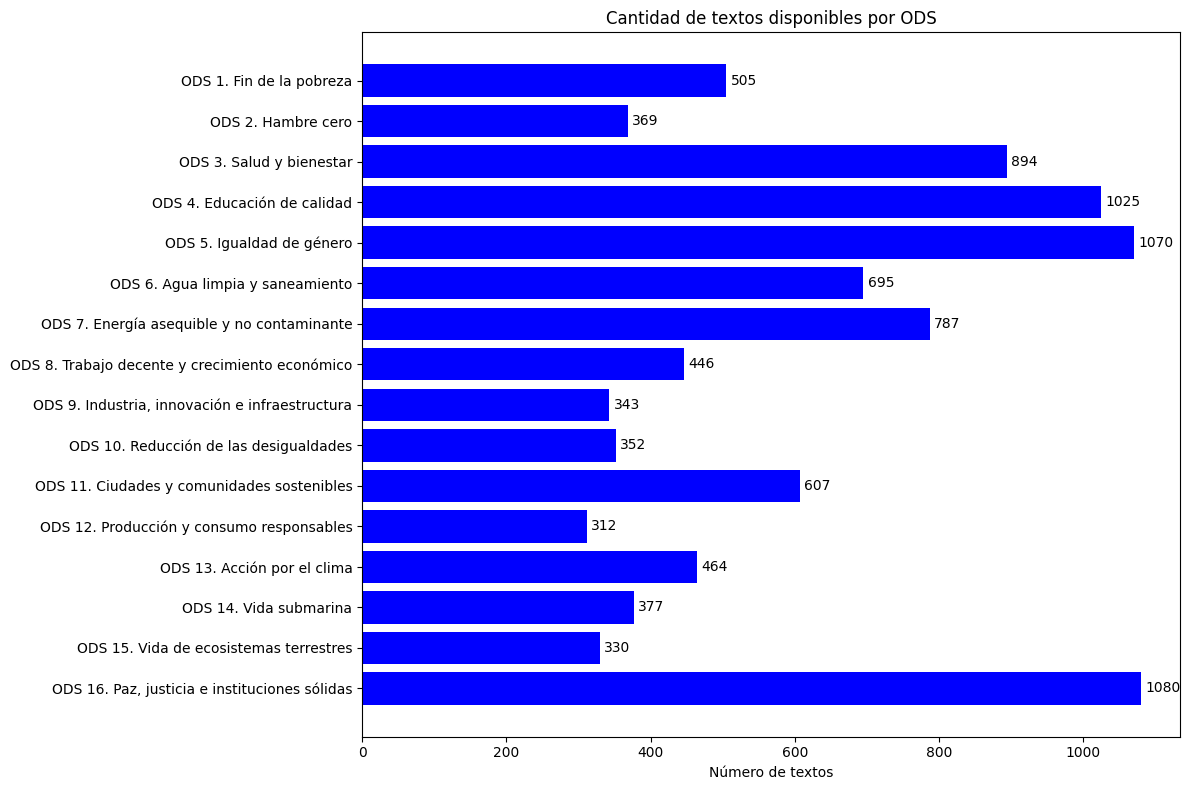

In [36]:
# Contar cuántos textos corresponden a cada ODS
conteo_ods = datos["ODS"].value_counts().sort_index()

print(conteo_ods)

# Crear las etiquetas con el número y el nombre del ODS
etiquetas = [
    f"ODS {ods}. {nombres_ods[ods]}"
    for ods in conteo_ods.index
]

# Construir la gráfica
plt.figure(figsize=(12, 8))

barras = plt.barh(etiquetas, conteo_ods.values, color = "blue")


plt.bar_label(barras, padding=3)
plt.title("Cantidad de textos disponibles por ODS")
plt.xlabel("Número de textos")
plt.ylabel("")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


La distribución presenta un desbalance a tener en cuenta. Los ODS 4, 5 y 16 tienen más de mil textos, mientras que los ODS 9, 12 y 15 tienen menos de 350. La clase más grande es aproximadamente un poco más de 3 veces mayor que la más pequeña. Por esta razón, el desempeño no se evaluará únicamente con exactitud; también se utilizará F1 macro para dar el mismo peso a cada ODS.


### 4.4. Longitud de los textos

La longitud de los textos se calcula a partir de su número de palabras. Esta revisión permite identificar si existen textos demasiado cortos o extensos y conocer las características generales de los documentos que serán utilizados por el modelo.


count    9656.000000
mean      111.017295
std        37.082212
min        24.000000
25%        82.000000
50%       105.000000
75%       135.000000
max       268.000000
Name: textos, dtype: float64


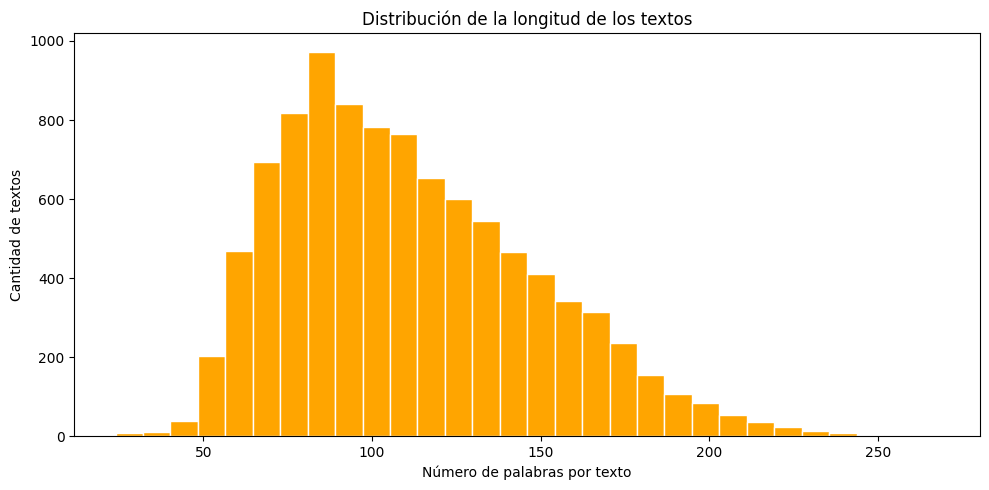

In [37]:
# Contar el número de palabras de cada texto
cantidad_palabras = datos["textos"].apply(
    lambda texto: len(texto.split()))

# Mostrar las principales estadísticas de la longitud de los textos
print(cantidad_palabras.describe())

# Construir el histograma
plt.figure(figsize=(10, 5))
plt.hist(cantidad_palabras, bins = 30, color = "orange", edgecolor ="white")

# Agregar los títulos de la gráfica
plt.title("Distribución de la longitud de los textos")
plt.xlabel("Número de palabras por texto")
plt.ylabel("Cantidad de textos")

plt.tight_layout()
plt.show()

En promedio, los textos contienen aproximadamente 111 palabras. El texto más corto tiene 24 palabras y el más largo 268. En general, no se observan textos excesivamente cortos o extensos, por lo que no es necesario limitar su longitud antes de aplicar TF-IDF.

### 4.5. Longitud de los textos según el ODS

Al realizar una gráfica tipo diagrama de cajas, se puede comparar la cantidad de palabras de los textos correspondientes a cada ODS. Esto ayuda a identificar si algunos ODS contienen textos generalmente más cortos o más extensos.


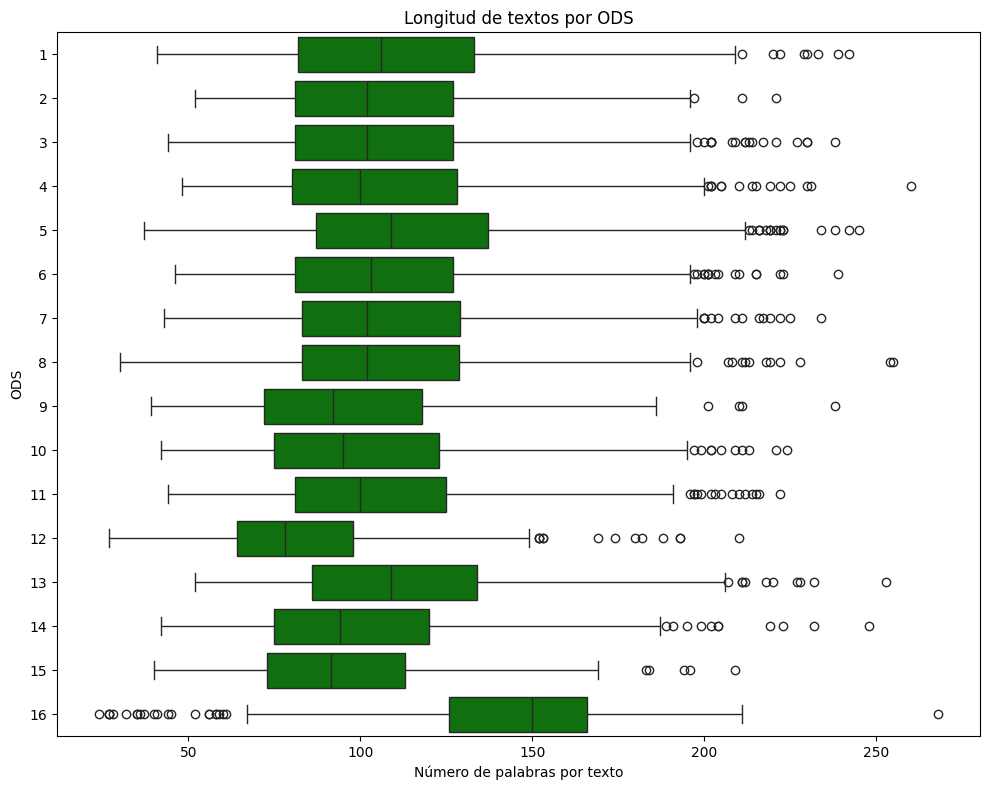

In [38]:
# Agregar al conjunto de datos el número de palabras calculado anteriormente
datos["n_palabras"] = cantidad_palabras

# Configuración de la gráfica para poder comparar entre ODS
plt.figure(figsize=(10, 8))
sns.boxplot(data=datos, x = "n_palabras", y = "ODS", orient = "h", color = "green")

# Agregar los títulos de la gráfica
plt.title("Longitud de textos por ODS")
plt.xlabel("Número de palabras por texto")
plt.ylabel("ODS")

plt.tight_layout()
plt.show()


Aunque se presentan algunas diferencias en la longitud de los textos, los rangos de los ODS se superponen. Por esto, la longitud por sí sola no parece suficiente para diferenciar las categorías; el modelo deberá apoyarse principalmente en las palabras y relaciones semánticas de cada texto.


### 4.6. Revisón de posible ruido o fuga de información en los datos

Finalmente, se verifica si los textos contienen direcciones web o menciones directas a los ODS. Estos elementos podrían introducir información poco útil o facilitar artificialmente la clasificación desviando la efectividad del modelo.

In [39]:
# Cantidad de textos que contienen direcciones web
textos_con_url = datos["textos"].str.contains("http|www", case=False).sum()

# Cantidad de textos que mencionan directamente ODS o SDG
textos_con_numero_ods = datos["textos"].str.contains(r"ODS\s*\d+", case=False).sum()

print(f"Textos con direcciones web: {textos_con_url}")
print(f"Textos que mencionan un ODS específico: {textos_con_numero_ods}")

Textos con direcciones web: 71
Textos que mencionan un ODS específico: 45


Hay 71 textos que contienen direcciones web y 45 textos que mencionan directamente un ODS específico. Frente a esto, se puede presentar un tipo de fuga de información ya que podrían proporcionar al modelo una información directamente relacionada sobre la categoría que debe predecir. Para evitarlo, durante el preprocesamiento se eliminarán las direcciones web y las referencias numéricas explícitas a los ODS. Ojo, Los textos no serán eliminados, ya que su contenido restante puede aportar información relevante.

# 5. Preparación de los textos

## 5.1. Separación de las variables
La columna `textos` contiene la información que utilizará el modelo para aprender. La columna `ODS` contiene la categoría que se desea predecir.

In [40]:
# Separar los textos y la variable objetivo
X = datos["textos"]
y = datos["ODS"]

print(f"Número de textos: {len(X):,}")
print(f"Número de categorías: {y.nunique()}")

Número de textos: 9,656
Número de categorías: 16


## 5.2. División entre entrenamiento y prueba

Se usa el 20 % de los textos para evaluar el modelo al final. El argumento stratify=y conserva una proporción semejante de cada ODS en ambos conjuntos buscando el mejor balance de los datos. La semilla 42 permite obtener la misma división al repetir el procedimiento.

Esta división se realiza antes de construir TF-IDF y SVD. De esta manera, el vocabulario y la reducción de dimensionalidad se aprenden únicamente con los textos de entrenamiento.

In [41]:
# Dividir los datos conservando la distribución de los ODS
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = RANDOM_STATE, stratify = y)

print(f"Textos de entrenamiento: {len(X_train):,}")
print(f"Textos de prueba: {len(X_test):,}")

Textos de entrenamiento: 7,724
Textos de prueba: 1,932


## 5.3. Preparación básica de los textos

La función **limpiar_texto()** realiza tres tareas sencillas:

1. Convierte el texto a minúsculas.
2. Elimina direcciones web.
3. Elimina referencias directas como **ods 6** u **objetivo de desarrollo sostenible 6** para reducir el riesgo de que el modelo encuentre la respuesta escrita en el texto.

In [42]:
# Función utilizada para limpiar cada texto
def limpiar_texto(texto):
    texto = texto.lower()

    # Eliminar direcciones web
    texto = re.sub(r"https?://\S+|www\.\S+", " ", texto)

    # Eliminar referencias directas al número de un ODS
    texto = re.sub(r"ods\s*\d+", " ", texto)
    texto = re.sub(
        r"objetivo(?:s)? de desarrollo sostenible\s*\d+",
        " ",
        texto,
    )
    texto = re.sub(r"objetivo\s+\d+", " ", texto)

    return texto


# Palabras frecuentes que no ayudan a diferenciar los temas ()
nltk.download('stopwords', quiet=True)
palabras_vacias = nltk.corpus.stopwords.words('spanish')

ejemplo_original = X_train.iloc[0]
ejemplo_limpio = limpiar_texto(ejemplo_original)

print("Ejemplo antes de la limpieza:")
print(ejemplo_original[:300])
print("\nEjemplo después de la limpieza:")
print(ejemplo_limpio[:300])


Ejemplo antes de la limpieza:
Por lo tanto, cabe esperar que el aumento de los niveles de ingresos posterior a la reforma de la asistencia social, tanto para los que tienen trabajo como para los que no tienen, tenga un efecto positivo en los niños. Una revisión de la evidencia sobre la reforma del bienestar y los resultados de l

Ejemplo después de la limpieza:
por lo tanto, cabe esperar que el aumento de los niveles de ingresos posterior a la reforma de la asistencia social, tanto para los que tienen trabajo como para los que no tienen, tenga un efecto positivo en los niños. una revisión de la evidencia sobre la reforma del bienestar y los resultados de l


## 5.4. Representación mediante TF-IDF

Una bolsa de palabras representa cada texto según los términos que contiene. TF-IDF complementa esta representación asignando mayor importancia a las palabras frecuentes dentro de un texto, pero menos comunes en el conjunto completo.

Para construir la representación TF-IDF se eliminan las palabras vacías y se conservan los términos presentes en al menos tres textos, pero no en más del 90 % de los textos. Se incluyen palabras individuales y combinaciones de dos palabras para representar expresiones como “cambio climático” o “agua potable”. Finalmente, el vocabulario se limita a 15.000 términos para controlar el tamaño de la matriz y facilitar la aplicación de LSA.

In [43]:
# se declara el objeto que se empleara mas adelante para aplicar la transformación TF-IDF en nuestros pipelines
vectorizador_lsa = TfidfVectorizer(
    preprocessor = limpiar_texto,
    stop_words = palabras_vacias,
    min_df = 3,
    max_df = 0.90,
    ngram_range = (1, 2),
    max_features = 15000,
)

# 6. Análisis semántico latente

## 6.1. ¿Qué es LSA?

Una palabra en si misma tiene un significado plano, pero sin un contexto que la rodee no es posible determinar de forma directa cual es el contexto o el tema sobre el cual se esta tratando, LSA es una tecnia de reduccion de dimensionalidad que permite, mediante transformaciones de algebra lineal, extraer temas comunes latentes o "topicos" desde el espacio de la matriz TF-IDF, esto es particularmente util para ejercicios de clasificacion como el que se esta llevando a cabo en este ejercicion.

A continuación se define entonces, el objeto LSA que se usara mas adelante para los pipelines:

In [44]:
lsa_obj = TruncatedSVD(
        n_components=100,
        random_state=RANDOM_STATE
    )

# 7. Elección del algoritmo de clasificación

Como criterios para la elección de un clasificador adecuado vale la pena resumir las caracteristicas del problema:

* Problema de clasificación de textos.
* 7,724 muestras disponibles para entrenamiento.
* 16 clases objetivo presentes en el conjunto de datos.

Ahora bien, en una tarea de clasificaciónde textos una de los objetivos mas importantes es poder asignar predicciones de clases con el menor grado de incertidumbre posible, o en otras palabras poder separar la asignacion de clases, ante esto, un clasificador que no base la separación entre las mismas en un unico criterio y opte por aplicar un margen entre ellas se intuye como la opción mas interesante.

En ese orden de ideas, para el presente ejercicio se hara uso de un clasificador de tipo LinearSVC en la medida que ofrece las siguientes ventajas:

* Intenta mantener la frontera de clasificación entre dos muentras cercanas lo mas lejos posible.
* Aplica una penalización sobre muestras que que se clasifiquen de forma incorrecta o esten dentro del margen de clasificación.
* Hace uso de regularización como parte del problema de optimización que resuelve para construir los clasificadores, previniendo asi sobreajuste; por defecto hace uso de norma L2, esto no se modificara.
* Solo se tiene un unico hiperparametro relacionado con el grado de regularización aplicada, lo cual facilita aplicar variaciones sobre el preprocesamiento de los datos al reducir el numero de combinaciones de modelo a evaluar.


In [45]:
lSVC_model = LinearSVC(C=0.1)

# 8. Entrenamiento de modelos y sintonización

## 8.1 Construcción del pipeline

Llegados a este punto se cuenta con las herramientas suficientes para construir un pipeline de entrenamiento de los datos con la siguiente configuración:

1. Datos 
2. Construcción de matriz TF-IDF (Aplicando eliminación de palabras vacias y depuración de URLs y referencias directas)
3. Ejecución de LSA para construir espacio semantico latente (generación de topicos basicamente)
4. Entrenaminento de clasificador LinearSVC 

In [46]:
#Definición de pipeline
pipeline_txt = Pipeline(steps=[
    ("vectorizador", vectorizador_lsa),
    ("lsa", lsa_obj),
    ("clasificador", lSVC_model)
])

## 8.2 Entrenamiento con busqueda de hiperparametros

En problemas de Machine learning el conocimiento y la experiencia de dominio suele dar intuiciones muy interesantes de cara a determinar los rangos de busqueda para los hiperparametros, en la medida que permite acotar los rangos de busqueda sobre intervalos ya conocidos, sin embargo, en caso que no se cuente con esta noción como es el caso de los autores de este trabajo, es preferible optar por una busqueda aleatoria de hiperparametros, no porque permita encontrar necesariamente el mejor modelo posible sino porque hace que la busqueda sobre el espacio de hiperparametros se ejecute de forma muchisimo mas eficiente, consiguiendo asi encontrar una solución con buen desempeño.

Como reglas mas importantes para definir el espacio de busqueda se tendran:

* Ignorar palabras muy raras (min_df).
* Ignorar palabras extremadamente comunes (max_df) 
* Aplicar o no penalizaciones sobre las clases desbalanceadas con el fin de incrementar el desempeño general, en la medida que en una grafica previa se mostro como todas las clases no tienen el mismo numero de muestras.
* Los demas parametros se asignan con rangos sugeridos en ejemplos consultados.

Finalmente, con el fin de prevenir aun mas el sobreajuste y mejorar la capacidad de generalización se aplica validación cruzada y como criterio de scoring se hace uso de f1-score, puesto que es la metrica que mejor balancea la relación entre clasificaciones correctas e incorrectas dando asi una medida mas holistica respecto al desempeño del clasificados.

In [47]:
# espacio para evaluacion de hiperparametros 
# (algunos son evientemente discretos, por eso se dejan como listas predefinidas)
param_dist = {
    # TF-IDF
    "vectorizador__ngram_range": [
        (1, 1),
        (1, 2),
    ],
    "vectorizador__min_df": randint(1, 6),
    "vectorizador__max_df": uniform(0.85, 0.15),
    "vectorizador__sublinear_tf": [True, False],

    # LSA
    "lsa__n_components": randint(50, 301),

    # LinearSVC
    "clasificador__C": loguniform(1e-3, 1e2),
    "clasificador__class_weight": [
        None,
        "balanced",
    ],
}

#se define el objeto de búsqueda aleatoria con validación cruzada estratificada
random_search = RandomizedSearchCV(
    estimator=pipeline_txt,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1_macro",
    n_jobs=-1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    verbose=1,
    random_state=RANDOM_STATE,
)

#>>>>><<<<<#
#---A ENTRENAR!!!
random_search.fit(X_train, y_train)
#>>>>><<<<<#

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rSVC(C=0.1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'clasificador__C': <scipy.stats....0019E10CFBCE0>, 'clasificador__class_weight': [None, 'balanced'], 'lsa__n_components': <scipy.stats....0019E0E44FBB0>, 'vectorizador__max_df': <scipy.stats....0019E0E6D9A90>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there ar

#### Tabla de resultados RandomSerchCV

In [48]:
results_rsearch_df = pd.DataFrame(random_search.cv_results_).sort_values(by="rank_test_score")
results_rsearch_df[['rank_test_score', 'mean_fit_time', 'mean_score_time', 'param_clasificador__C', 'param_clasificador__class_weight', 
                    'param_lsa__n_components', 'param_vectorizador__max_df', 'param_vectorizador__min_df', 'mean_test_score', 
                    'std_test_score', 'param_vectorizador__ngram_range']].head(10)

,rank_test_score,mean_fit_time,mean_score_time,param_clasificador__C,param_clasificador__class_weight,param_lsa__n_components,param_vectorizador__max_df,param_vectorizador__min_df,mean_test_score,std_test_score,param_vectorizador__ngram_range
21,1,19.880400,0.366343,0.349023,balanced,278,0.887394,5,0.844911,0.008300,"(1, 1)"
28,2,22.823193,0.585093,0.392603,None,229,0.904544,1,0.835382,0.009035,"(1, 2)"
20,3,20.397296,0.634702,0.137311,balanced,173,0.866184,1,0.834581,0.009433,"(1, 2)"
17,4,20.499038,0.442752,0.045133,balanced,296,0.896647,5,0.833975,0.007122,"(1, 1)"
25,5,24.839801,0.727656,0.060463,balanced,274,0.890820,3,0.832605,0.003787,"(1, 2)"
12,6,25.853523,0.605397,0.042330,balanced,286,0.890702,5,0.832562,0.008500,"(1, 2)"
2,7,14.757962,0.592002,3.470267,balanced,102,0.995486,4,0.829322,0.010604,"(1, 2)"
23,8,18.243781,0.574025,44.513143,None,111,0.945011,4,0.828219,0.010095,"(1, 2)"
4,9,23.724589,0.807091,0.144453,None,268,0.941778,2,0.827824,0.007949,"(1, 2)"
19,10,21.494532,0.416391,17.561804,None,267,0.885398,3,0.824386,0.006379,"(1, 1)"


## 8.3 Analisis de resultados entrenamiento

### 8.3.1 Comportamiento del numero de componentes


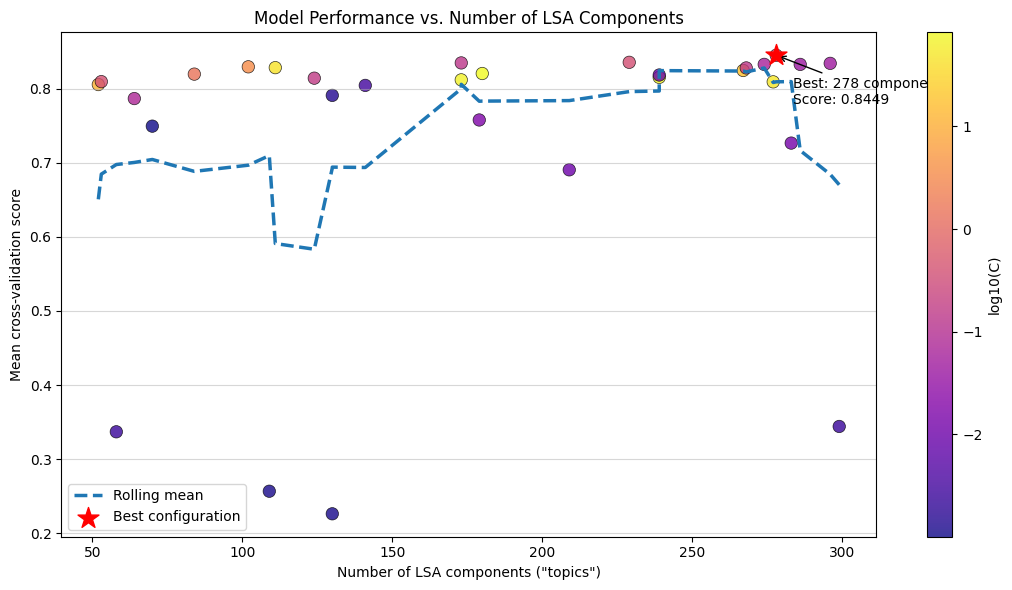

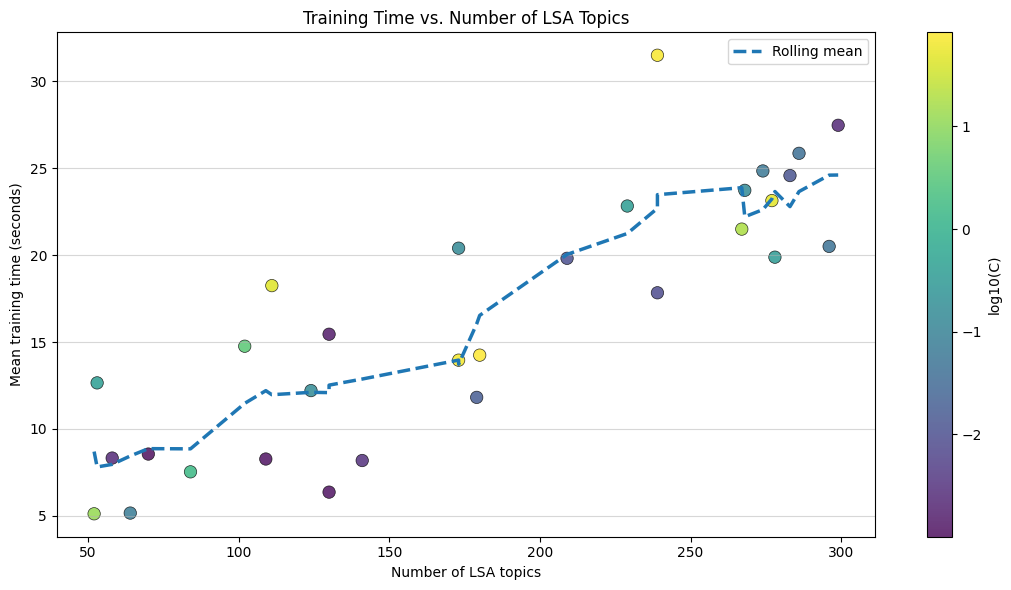

In [49]:
def plot_lsa_results(results_df, metric="score", rolling_window=5, cmap="plasma"):
    df = results_df.copy()
    df["n_components"] = df["param_lsa__n_components"].astype(int)
    df["C"] = df["param_clasificador__C"].astype(float)
    df = df.sort_values("n_components")

    cfg = {
        "score": ("mean_test_score", "Mean cross-validation score",
                  "Model Performance vs. Number of LSA Components",
                  'Number of LSA components ("topics")'),
        "time": ("mean_fit_time", "Mean training time (seconds)",
                 "Training Time vs. Number of LSA Topics",
                 "Number of LSA topics")
    }

    if metric not in cfg:
        raise ValueError("metric must be 'score' or 'time'")

    y, ylabel, title, xlabel = cfg[metric]
    rolling = df[y].rolling(rolling_window, center=True, min_periods=1).mean()
    best = df.loc[df["mean_test_score"].idxmax()]

    fig, ax = plt.subplots(figsize=(11, 6))
    sc = ax.scatter(df["n_components"], df[y], c=np.log10(df["C"]),
                    cmap=cmap, s=80, alpha=.8, edgecolors="black", linewidths=.5)

    ax.plot(df["n_components"], rolling, "--", lw=2.5, label="Rolling mean")

    if metric == "score":
        ax.scatter(best["n_components"], best[y], color="red", marker="*", s=250,
                   label="Best configuration", zorder=5)
        ax.annotate(f'Best: {best["n_components"]} components\nScore: {best[y]:.4f}',
                    (best["n_components"], best[y]), xytext=(12, -35),
                    textcoords="offset points", arrowprops={"arrowstyle": "->"})

    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    fig.colorbar(sc, ax=ax, label="log10(C)")
    ax.grid(axis="y", alpha=.5)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_lsa_results(results_rsearch_df, "score", cmap="plasma")
plot_lsa_results(results_rsearch_df, "time",  cmap="viridis")

*>> Analisis*

La ultima grafica generada permite mostrar la evolución del puntaje f1 en función del numero de componentes (topicos) y valor de regularización durante la busqueda de hiperparametros, es posible extraer las siguientes conclusiones:

* Los modelos que aplican balanceo de clases son mayoritarios en el top 10 (incluso si la segunda mejor opcion es desbalanceada), esto se explica en parte por la metrica de evaluación escogida, puesto que el f1-score premia clasificadores que tengan un desempeño en promedio mejor sobre todas las clases; de haberse escogido metricas como el accuracy o el recall es muy probable que las opciones desbalanceadas resultaran favorecidas, para el ejercicio actual y la naturaleza de los datos disponibles se considera que se tomo la mejor decision posible al emplear la metrica elegida.

* El asignar un mayor  numero de compoentes antes de generar la clasificación no necesariamente representa una mejora en el desempeño del modelo, pero si incrementa de forma significativa el costo computacional al demandar el procesamiento de mas informacion, tomense como ejemplo los clasificadores de la posicion 1 vs la posicion 7, el primero ofrece una mejor en desempeño de alrededor aprox 1.9% a costa de incrementar aprox 172% el numero de componentes y aprox 36% el tiempo de entrenamiento; el incremento visto en el tiempo de evaluacion para el caso de menos componentes se explica por el ngram_range, en el caso de menos componentes se aplica (1,2) generando un mayor tamaño de la matriz TF-IDF y esto importa en el paso de evaluación.

### 8.3.2 Efecto de la regularización y el ngram

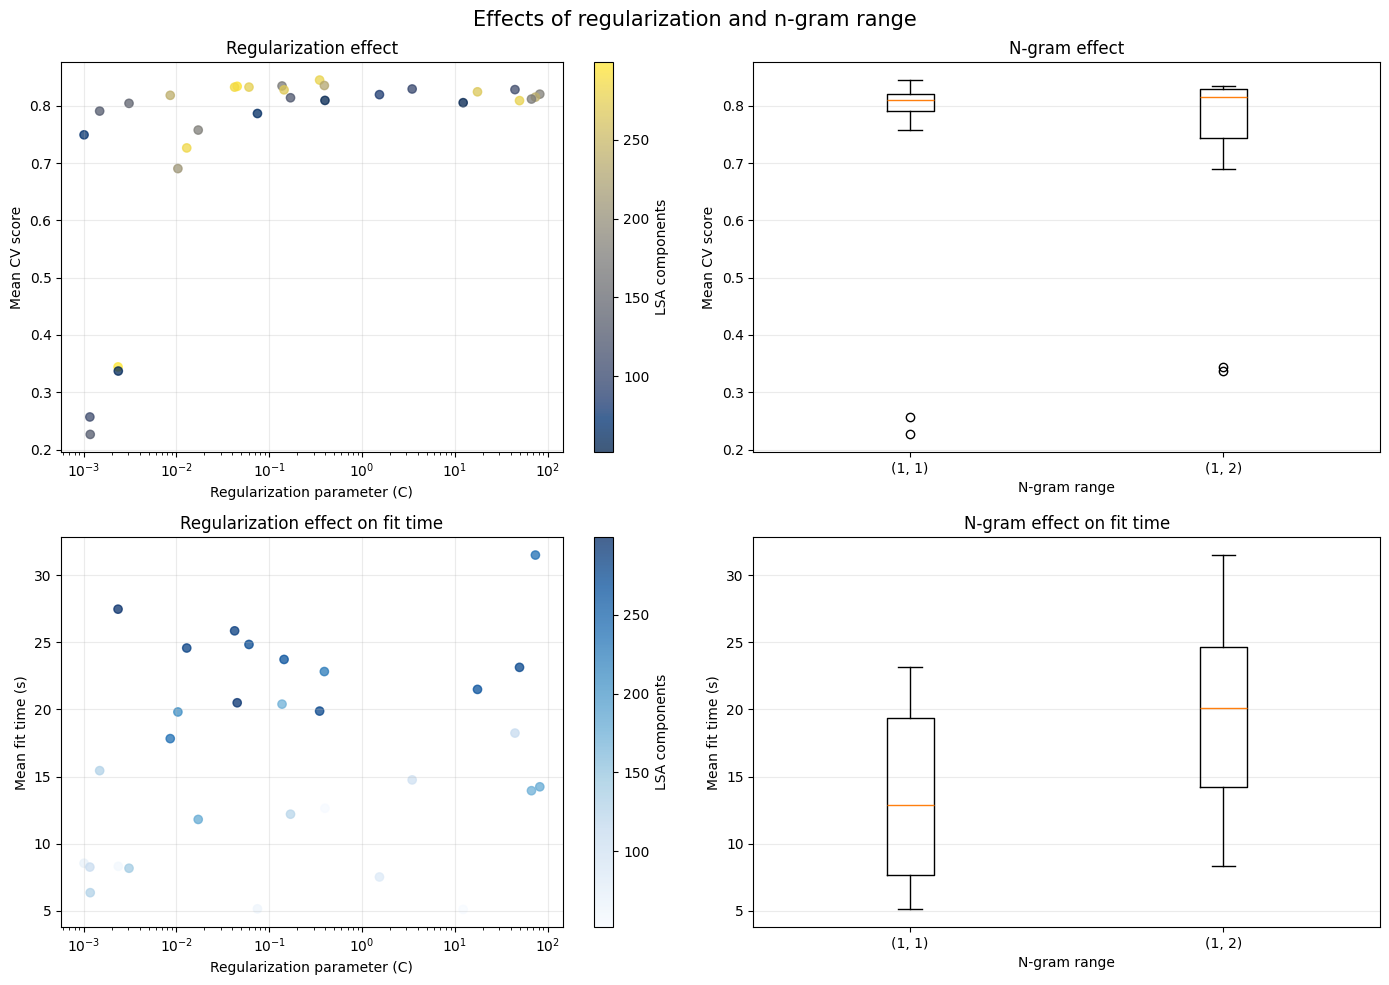

In [50]:
df = results_rsearch_df.copy()
df["ngram_range"] = df["param_vectorizador__ngram_range"].astype(str)
df["n_components"] = df["param_lsa__n_components"].astype(int)
df["C"] = df["param_clasificador__C"].astype(float)

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    ("mean_test_score", "Mean CV score", "cividis"),
    ("mean_fit_time", "Mean fit time (s)", "Blues")
]

groups = df.groupby("ngram_range", sort=True)
labels = list(groups.groups)

for row, (metric, ylabel, cmap) in enumerate(metrics):

    # C effect
    sc = ax[row, 0].scatter(
        df["C"], df[metric],
        c=df["n_components"], cmap=cmap, alpha=.75
    )
    ax[row, 0].set_xscale("log")
    ax[row, 0].set(
        xlabel="Regularization parameter (C)",
        ylabel=ylabel,
        title=f"Regularization effect{' on fit time' if row else ''}"
    )
    ax[row, 0].grid(alpha=.25)
    fig.colorbar(sc, ax=ax[row, 0], label="LSA components")

    # N-gram effect
    ax[row, 1].boxplot(
        [g[metric].values for _, g in groups],
        tick_labels=labels
    )
    ax[row, 1].set(
        xlabel="N-gram range",
        ylabel=ylabel,
        title=f"N-gram effect{' on fit time' if row else ''}"
    )
    ax[row, 1].grid(axis="y", alpha=.25)

fig.suptitle("Effects of regularization and n-gram range", fontsize=15)
plt.tight_layout()
plt.show()

*>> Analisis*

* Los valores de regularización bajos por norma general penalizan el redimiento de los modelos, sin importar el numero de componentes LSA que se evaluen, esto es un sintoma de overfitting, donde se "memorizan" los datos de entrenamiento pero se afecta la capacidad de generalización.

* El parametro de Ngram en TF-IDF permite determinar si se emplean palabras individuales o se generan combimaciones de vecinos para captura de información, para el ejercicio se observa como el emplear palabras unicas resulta en menor variancia sobre la metrica de desempeño respecto a los casos donde se emplean combinaciones.

* El valor del parametro de regularización es irrelevante respecto al tiempo de entrenamiento, resulta evidente como este se ve influenciado en mayor medida por el numero de componentes LSA.

* El uso de un NGram que genere una matriz TF-IDF con combinaciones de vecinos, incrementa de forma evidente los tiempos de entrenamiento puesto que sube el costo computacional, de acuerdo con los resultados vistos en la tabla resumen, para casos con menor numero de componentes LSA el emplear un NGram combinando vecinos incrementaba el performance a costa de subir ligeramente el tiempo evaluación, esto es, el usar un menor numero de topicos se compensa con mayor contexto en la matriz TF-IDF.

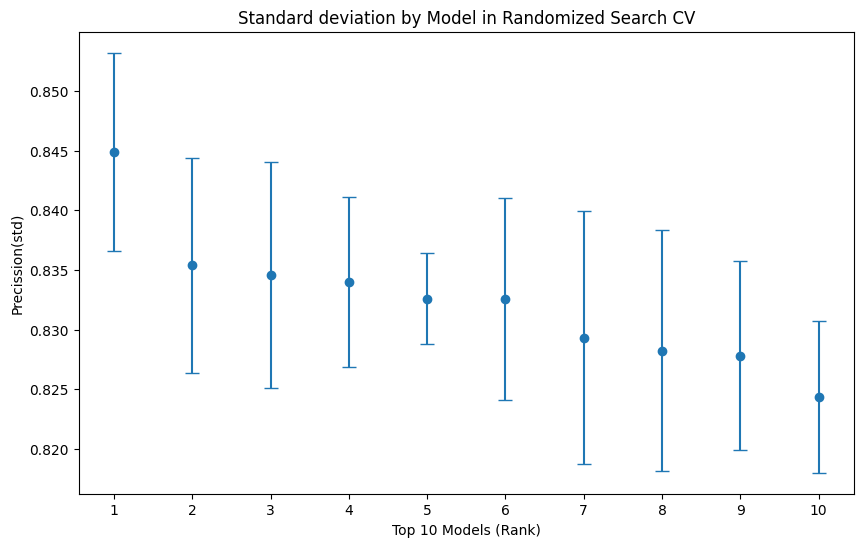

In [83]:
#grafica de la desviación estandar por cada modelo de la búsqueda aleatoria top 10
df = results_rsearch_df.head(10).copy()

plt.figure(figsize=(10, 6))
plt.errorbar(x=df['rank_test_score'], y=df['mean_test_score'], yerr=df['std_test_score'], fmt='o', capsize=5)
plt.xlabel('Top 10 Models (Rank)')
plt.ylabel('Precission(std)')
plt.title('Standard deviation by Model in Randomized Search CV')
plt.xticks(df['rank_test_score'], df['rank_test_score'])
plt.show()


Respecto a la estabilidad de los modelos, para las 10 mejores alternativas encontradas se observa un comportamiento muy similar en la estabilidad de los scores de validación cruzada, de tal forma que no es un buen criterio para seleccionar una opcion sobre otra.

# 9. Evaluación del modelo

En la sección anterior se llego a conclusiones interesantes, una de ellas implica que no necesariamente el mejor modelo generado por la busqueda puede ser el mas apetecible, sin embargo, en orden de evaluar el mejor modelo contra los datos de validación se usara el best_model:

In [51]:
#Mostrar parametros mejor estimador
best_estimator = random_search.best_estimator_
best_params = random_search.best_params_

#Mostrar parametros mejor estimador
best_params

{'clasificador__C': np.float64(0.34902252478382495),
 'clasificador__class_weight': 'balanced',
 'lsa__n_components': 278,
 'vectorizador__max_df': np.float64(0.8873938343723312),
 'vectorizador__min_df': 5,
 'vectorizador__ngram_range': (1, 1),
 'vectorizador__sublinear_tf': True}

Notese el compromiso entre numero de componentes LSA y NGram, mas componentes a costa de usar palabras individuales para generar la matriz TF-IDF.

## 9.1 Predicción sobre el conjunto de prueba

Simplemente se genera la predicción de etiquetas haciendo uso del conjunto de prueba que se separo previamente:

In [52]:
y_pred = best_estimator.predict(X_test)

## 9.2 Resultados generales

En esta sección se calcula la matriz de confusión para todo el modelo y se analiza su desempeño general.

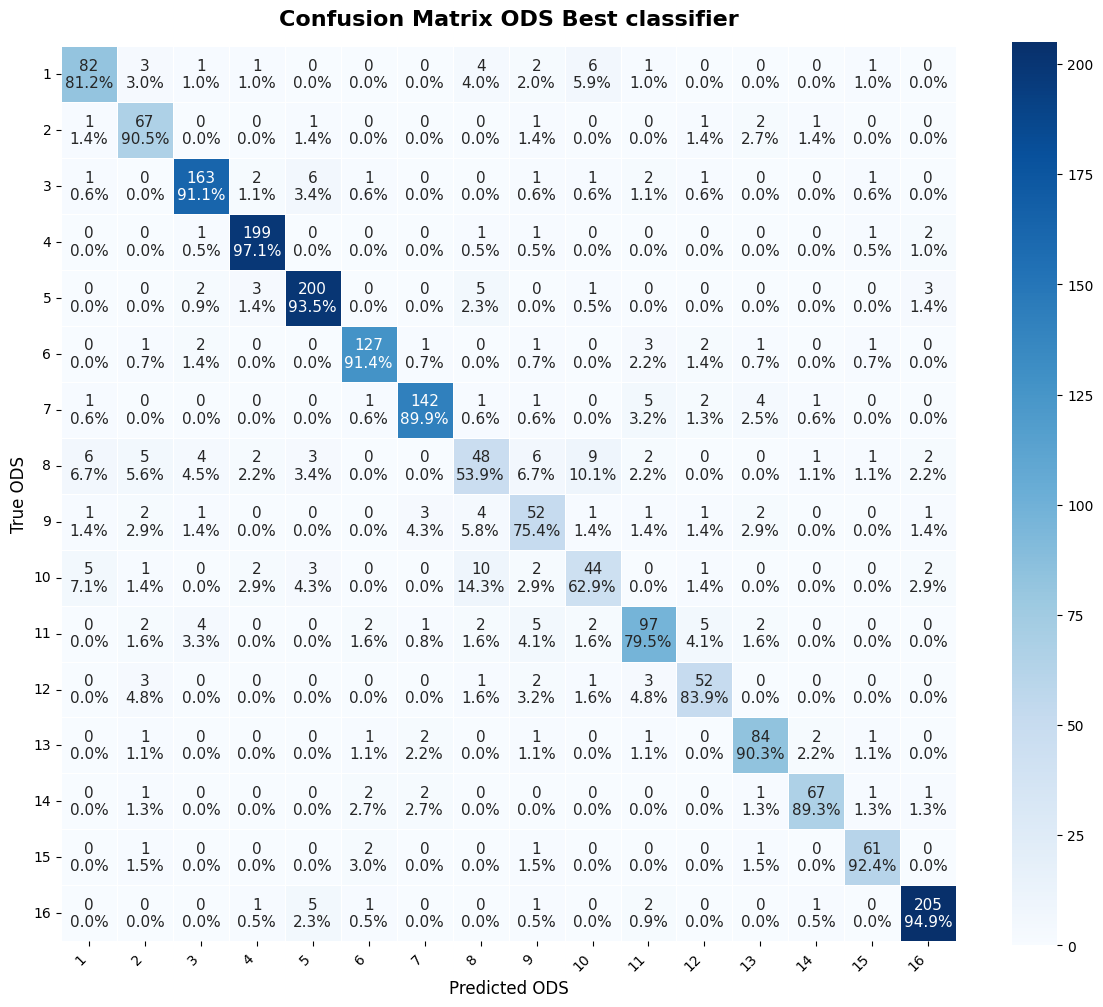

In [53]:
#calcular y visualizar matriz de confusión general
conf_matrix_general = pd.crosstab(y_test, y_pred, rownames=["Actual"], colnames=["Predicted"], margins=True)

#grafica de matriz de confusión
cm_df = conf_matrix_general.drop(index="All", columns="All", errors="ignore") #borrar la fila y columna de totales para la visualización

cm = cm_df.to_numpy()

# calcular porcentajes por celda
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

annot = np.empty_like(cm, dtype=object)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n{cm_pct[i, j]:.1f}%"

plt.figure(figsize=(12, 10))

sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", cbar=True, linewidths=0.5,
    linecolor="white", square=True, annot_kws={"size": 11}, xticklabels=cm_df.columns,
    yticklabels=cm_df.index
)

plt.title("Confusion Matrix ODS Best classifier", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Predicted ODS", fontsize=12)
plt.ylabel("True ODS", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

A partir de las matriz de confusion es posible calcular las 4 metricas clasicas que aplican para modelos de clasificación, pero con una importante salvedad, en la medida que se tienen multiples clases los calculos de algunos valores varian un poco en como se ejecutan:

* TP = Las diagonales de cada clase.
* FP = Los demas valores predichos para la clase que no estaran en la diagonal.
* FN = Los demas valores reales para la clase que no estaran en la diagonal.

Calculados estos valores para cada clase, se aplica una tecnica de ponderación para obtener un valor general, considerando que se trata de un problema de clases desbalanceadas y que el mejor clasificador obtenido se hizo aplicando balance, se usa entonces un metodo ofrecido por librerias que tiene en cuenta el numero de elementos de cada clase en el calculo aunque ata un poco los valores a que tan bien se comporta el clasificador sobre este conjunto de datos en particular.

In [54]:
accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall_macro = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1_macro = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f'> Valor de las metricas para el conjunto de test sobre todo el modelo:\n')
print(f"* Accuracy:  {accuracy:.4f}")
print(f"* Precision: {precision_macro:.4f}")
print(f"* Recall:    {recall_macro:.4f}")
print(f"* F1-score:  {f1_macro:.4f}")


> Valor de las metricas para el conjunto de test sobre todo el modelo:

* Accuracy:  0.8747
* Precision: 0.8741
* Recall:    0.8747
* F1-score:  0.8738


*Analisis metricas*

* A modo general, de acuerdo con la matriz de confusion las clases mayoritarias respecto al numero de datos tienen porcentajes altos de aciertos en la clasificación, en tanto que los peores valores se ven sobre clases minoritarias, la ponderación por pesos en el calculo de las metricas explica el porque estas ultimas no penalizan tanto el valor.

* El dato del F1-Score de 0.8738 nos indica que el clasificador generado posee una capacidad de generalización bastante aceptable, esto se refuerza tambien por la cercania en valores que tiene con las demas metricas.


## 9.3 Analisis por ODS

### 9.3.1 Metricas por ODS

Ahora se construye un reporte de metricas especifico para evaluar el comportamiento de cada ODS:

In [55]:
#reporte detallado por cada clase por cada clase de la matriz de confusion
detailed_report = classification_report(y_test, y_pred, zero_division=0)
detailed_report_df = pd.DataFrame([x.split() for x in detailed_report.splitlines()[2:-3]], columns=["ODS", "Precision", "Recall", "F1-score", "Support"])
detailed_report_df.drop(detailed_report_df.tail(1).index,inplace=True) 

#ordenar por F1-score
detailed_report_df.sort_values(by="F1-score", ascending=False, inplace=True)
detailed_report_df

,ODS,Precision,Recall,F1-score,Support
3,4,0.95,0.97,0.96,205
15,16,0.95,0.95,0.95,216
4,5,0.92,0.93,0.93,214
5,6,0.93,0.91,0.92,139
6,7,0.94,0.90,0.92,158
2,3,0.92,0.91,0.91,179
13,14,0.92,0.89,0.91,75
14,15,0.90,0.92,0.91,66
12,13,0.87,0.90,0.88,93
0,1,0.85,0.81,0.83,101


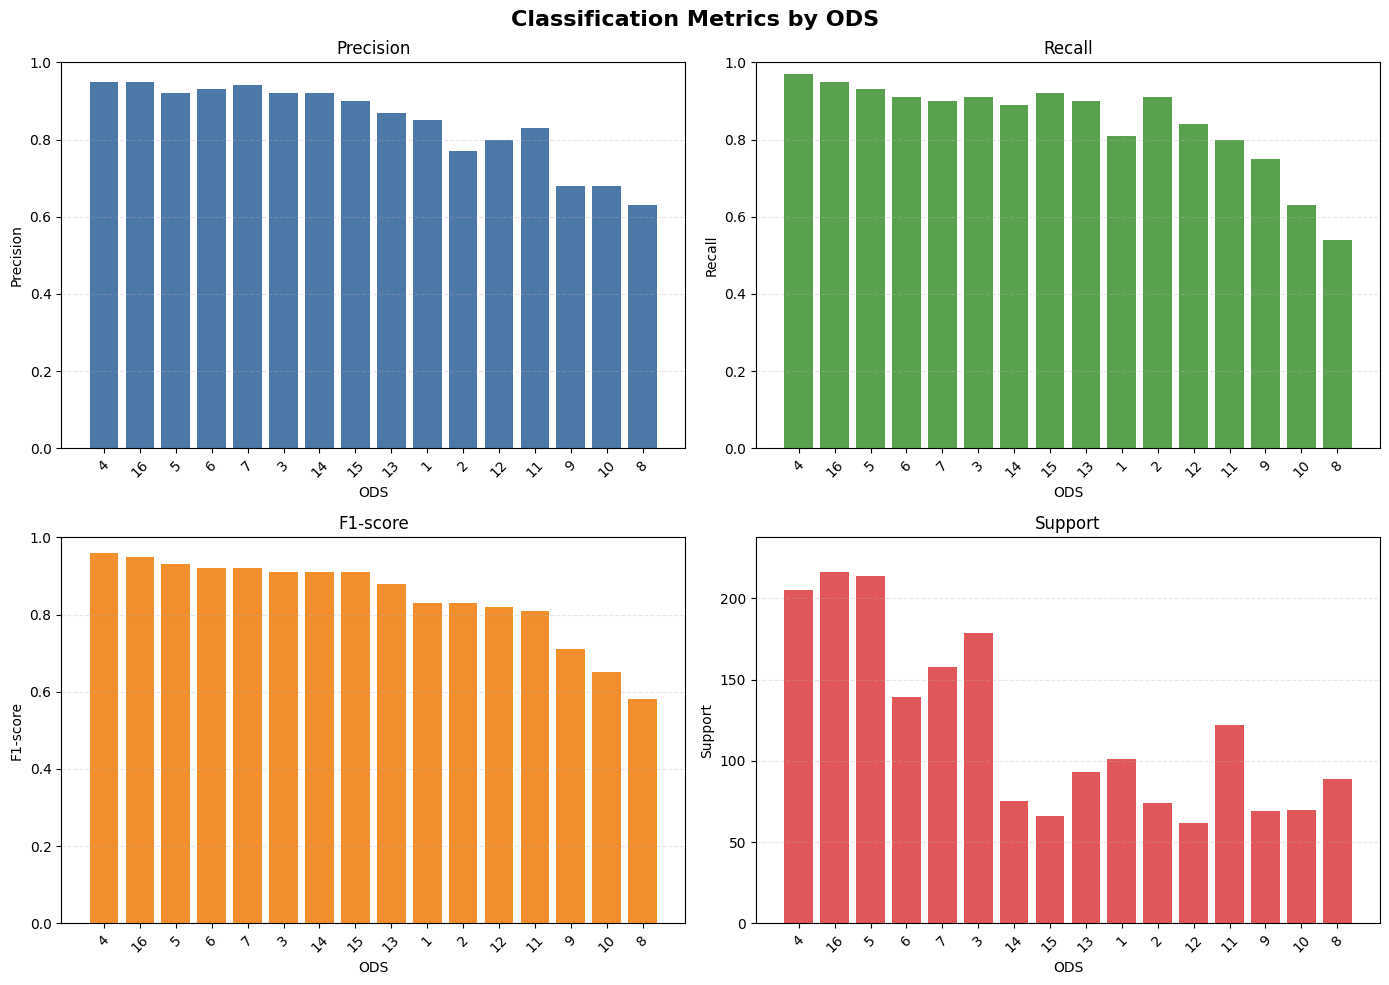

In [56]:
metrics = ["Precision", "Recall", "F1-score", "Support"]
colors = ["#4C78A8", "#59A14F", "#F28E2B", "#E15759"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, metric, color in zip(axes.flat, metrics, colors):
    values = pd.to_numeric(detailed_report_df[metric], errors="coerce")
    x = range(len(values))

    ax.bar(x, values, color=color)
    ax.set(
        title=metric,
        xlabel="ODS",
        ylabel=metric,
        xticks=x,
        xticklabels=detailed_report_df["ODS"],
    )
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0, 1 if metric != "Support" else values.max() * 1.1)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.suptitle("Classification Metrics by ODS", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

La metrica de soporte simplemente indica cuantas metricas reales pertencen a la clase en el conjunto de test; el ranking de los ODS de mejor calsificado a peor queda entonces:

In [65]:
print('>> Ranking de ODS por F1-score (de mayor a menor):\n')

for ods in detailed_report_df.sort_values(by="F1-score", ascending=False)["ODS"]:
    print(f"-> {ods}: {nombres_ods[int(ods)]}")

>> Ranking de ODS por F1-score (de mayor a menor):

-> 4: Educación de calidad
-> 16: Paz, justicia e instituciones sólidas
-> 5: Igualdad de género
-> 6: Agua limpia y saneamiento
-> 7: Energía asequible y no contaminante
-> 3: Salud y bienestar
-> 14: Vida submarina
-> 15: Vida de ecosistemas terrestres
-> 13: Acción por el clima
-> 1: Fin de la pobreza
-> 2: Hambre cero
-> 12: Producción y consumo responsables
-> 11: Ciudades y comunidades sostenibles
-> 9: Industria, innovación e infraestructura
-> 10: Reducción de las desigualdades
-> 8: Trabajo decente y crecimiento económico


### 9.3.2 Analisis de resultados

* Respecto a al F1 Score, notese como 13 de los 16 ODS presentan un rendimiento superior a 0.8, las mejores clases siendo la 4 y 16, en tanto que los objetivos 9, 10 y 8 manifiestan un comportamiento poco deseable, a priori no parece tratarse de un problema con el numero de muestras puesto que otras clases con valores similares generan mejores resultados, se van a tomar como ejemplos un par de muestras de la mejor clase y se contrastaran con la peor:

In [80]:
#Consolidar el conjunto de test, con los labels reales y predichos
test_cons_df = pd.DataFrame({
    "textos": X_test,
    "ODS_real": y_test,
    "ODS_pred":y_pred
})

#calcular columna con diferencias
test_cons_df["Clasificado"] = ~(test_cons_df["ODS_real"] != test_cons_df["ODS_pred"])

display(test_cons_df.head(5))

#Ejemplos de textos bien clasificados
print(">>>> Ejemplos de textos bien clasificados ODS 4: "+ nombres_ods[4]+ '\n')

aux_ = test_cons_df[(test_cons_df["ODS_real"] == 4) & (test_cons_df["Clasificado"] == True)]["textos"].sample(3, random_state=RANDOM_STATE)
for i in range(0,2):
    print(textwrap.fill('-'+aux_.iloc[i], width=170), "\n")

#ejemplos de textos bien clasificados ODS 8
print(">>>> Ejemplos de textos bien clasificados ODS 8: "+ nombres_ods[8]+ '\n')
aux_ = test_cons_df[(test_cons_df["ODS_real"] == 8) & (test_cons_df["Clasificado"] == True)]["textos"].sample(3, random_state=RANDOM_STATE)
for i in range(0,2):
    print(textwrap.fill('-'+aux_.iloc[i], width=170), "\n")


,textos,ODS_real,ODS_pred,Clasificado
5100,"En la última década, muchos de los procesos de...",5,5,True
4959,La seguridad alimentaria se menciona solo una ...,2,2,True
9248,Las políticas de gestión y reciclaje de residu...,11,12,False
4619,Los patrones detectados fueron diferentes para...,5,4,False
4808,En las economías latinoamericanas de renta med...,10,10,True


>>>> Ejemplos de textos bien clasificados ODS 4: Educación de calidad

-Ministerio de Educación de Bangladesh, 2012). A fines de la década de 1980, el gobierno puso gran énfasis en la mejora del sistema de educación primaria en un intento
por aumentar la tasa de alfabetización; en ese momento se emprendió un plan importante para establecer una escuela primaria por cada 2000 personas en Bangladesh. La
educación superior, asimismo, tiene tres corrientes: general (ciencias puras y aplicadas, artes, negocios y ciencias sociales), Madraza y educación tecnológica, que
incluye agricultura, ingeniería, medicina, tecnología textil, del cuero y tecnología de la información y la comunicación (TIC). (Ministerio de Educación de Bangladesh,
2004). 

-El proyecto de implantación de la EPICT en el sistema educativo austriaco se lleva a cabo desde el otoño de 2007. El informe nacional dedicado a Austria2 (actualizado y
revisado por última vez en agosto de 2008) especifica que esta implantación afecta t

Es notable como para la clase mejor clasificada la palabra central del tema: "educación" o una variacion similar aparece en varias ocasciones dentro del contenido del texto, en tanto que para la clase con menor perfomance, el contenido de las muestras parece ser un poco mas ambiguo incluso cuando se lee por parte de un ser humano.

* Las metricas del recall y la precision emulan de forma parecida a la metrica del F1-Score, indicando un buen comportamiento general.

* El aplicar balanceo de clases durante la etapa de entrenamiento se hace especialmente notorio en la etapa de evaluación, notese como el desempeño para la mayoria de ODS es comparable a pesar de contar con diferentes numeros de muestras disponibles.

## 9.4 LSA y evaluación cualitativa de los topicos respecto a los ODS

### 9.4.1 Revision de palabras mas importantes


In [134]:
#Desde el mejor estimador se extrae el vectorizador y el clasificador para poder analizar los coeficientes de cada ODS
vect_best = best_estimator.named_steps["vectorizador"]
lsa_best = best_estimator.named_steps["lsa"]
best_lsa_components = lsa_best.components_

#Palabras mas importantes por topico
print('>> Palabras más importantes por tópico (LSA):\n')
feature_names = vect_best.get_feature_names_out()

n_topics = lsa_best.n_components
n_top_words = 10

topic_info = []

for topic_idx, component in enumerate(lsa_best.components_):

    top_indices = component.argsort()[-n_top_words:][::-1]

    words = feature_names[top_indices]
    weights = component[top_indices]

    topic_info.append({
        "topic": topic_idx,
        "top_words": ", ".join(words),
        "weights": weights
    })

topic_df = pd.DataFrame(topic_info)

topic_df['top_words'].values
#Quizas valdria la pena agreagar una interpretación humana leyendo uno a uno, pero son 277!!!

>> Palabras más importantes por tópico (LSA):



array(['países, mujeres, desarrollo, pueden, políticas, puede, agua, educación, ocde, mayor',
       'mujeres, hombres, pobreza, ingresos, género, laboral, educación, empleo, niños, trabajo',
       'derechos, mujeres, derecho, humanos, género, internacional, artículo, igualdad, hombres, violencia',
       'educación, estudiantes, escuelas, aprendizaje, atención, escuela, salud, docentes, evaluación, calidad',
       'mujeres, género, hombres, igualdad, políticas, energía, desarrollo, participación, empresas, trabajo',
       'salud, atención, servicios, mental, agua, pacientes, médicos, calidad, primaria, enfermedades',
       'agua, aguas, mujeres, subterráneas, residuales, gestión, riego, hídricos, potable, estudiantes',
       'energía, electricidad, renovables, energética, derecho, energías, mujeres, salud, generación, atención',
       'países, millones, climático, ocde, desarrollo, financiación, género, mundial, 2015, años',
       'países, climático, ocde, cambio, datos, puede,

### 9.4.2 Asociación topicos por ODS

In [100]:
#Convertir los documntos de prueba a la representación TF-IDF
X_tfidf = vect_best.transform(X_test)

X_lsa = lsa_best.transform(X_tfidf)

print("LSA shape:", X_lsa.shape)

LSA shape: (1932, 278)


In [110]:
#asociacion de topicos con ODS reales
df_lsa = pd.DataFrame(
    X_lsa,
    columns=[
        f"Topic_{i}"
        for i in range(X_lsa.shape[1])
    ]
)
df_lsa["label"] = np.asarray(y_test.values)

topic_by_label = ( df_lsa.groupby("label").mean())
topic_by_label

,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,...,Topic_268,Topic_269,Topic_270,Topic_271,Topic_272,Topic_273,Topic_274,Topic_275,Topic_276,Topic_277
label,,,,,,,,,,,,,,,,,,,,,
1,0.145013,0.077312,-0.031388,-0.047491,-0.072014,-0.007017,-0.026139,-0.065626,-0.023918,-0.030053,...,-0.003001,-0.000062,0.001739,1.083767e-03,-0.000498,-0.000884,-0.001032,0.000197,0.000842,-0.001598
2,0.130832,-0.008341,-0.042684,-0.033787,-0.008741,-0.002385,-0.008507,-0.003090,-0.011267,-0.009937,...,0.001598,0.000048,-0.005142,1.142089e-03,0.002353,-0.002629,-0.002793,-0.001641,-0.003909,0.000547
3,0.130335,0.024297,-0.016116,0.041408,-0.045424,0.103573,-0.019424,0.029537,0.031043,0.021762,...,-0.001139,0.004002,0.002409,-5.473979e-07,0.000372,0.000933,0.000851,-0.000687,-0.000830,-0.001178
4,0.131301,0.023184,0.008410,0.115395,-0.017172,-0.062342,0.021850,0.008253,-0.007709,0.000606,...,-0.000845,0.000135,0.000139,1.886002e-03,-0.001528,-0.000591,-0.000490,-0.001612,-0.001340,-0.003201
5,0.147496,0.073019,0.080256,-0.036344,0.083032,0.016870,0.021628,0.009388,0.020338,0.008327,...,-0.000346,-0.001208,-0.001640,1.976867e-03,0.001558,0.000908,0.001742,-0.000998,0.000468,-0.002896
6,0.129961,-0.063303,-0.058968,-0.013916,0.015364,0.038874,0.114194,-0.032363,-0.030628,0.009403,...,-0.001404,0.001288,-0.001530,-7.559546e-04,0.002987,-0.001779,0.000472,-0.000890,-0.001343,0.003008
7,0.129040,-0.047366,-0.071889,-0.038134,0.024928,-0.037569,-0.035745,0.093233,-0.002760,0.017109,...,-0.003809,0.000320,0.000450,-6.452580e-04,-0.001148,-0.003998,-0.000559,0.003012,-0.000939,-0.001505
8,0.132699,0.037724,-0.009044,-0.010693,-0.007182,-0.004611,-0.017275,0.001613,-0.021187,-0.008314,...,0.001302,-0.000252,0.002564,-2.923322e-03,-0.002812,0.000027,0.000021,-0.002845,0.001576,0.000072
9,0.128657,-0.030514,-0.022801,0.009154,0.019361,-0.002983,-0.030579,0.003080,0.002325,-0.034363,...,0.001616,-0.001052,0.000515,-1.010098e-03,-0.000972,0.001843,-0.001557,0.001578,0.002945,-0.000337


### 9.4.3 importancia promedio por cada topico

Calcular el valor promedio de importancia de cada topico sobre los ods:

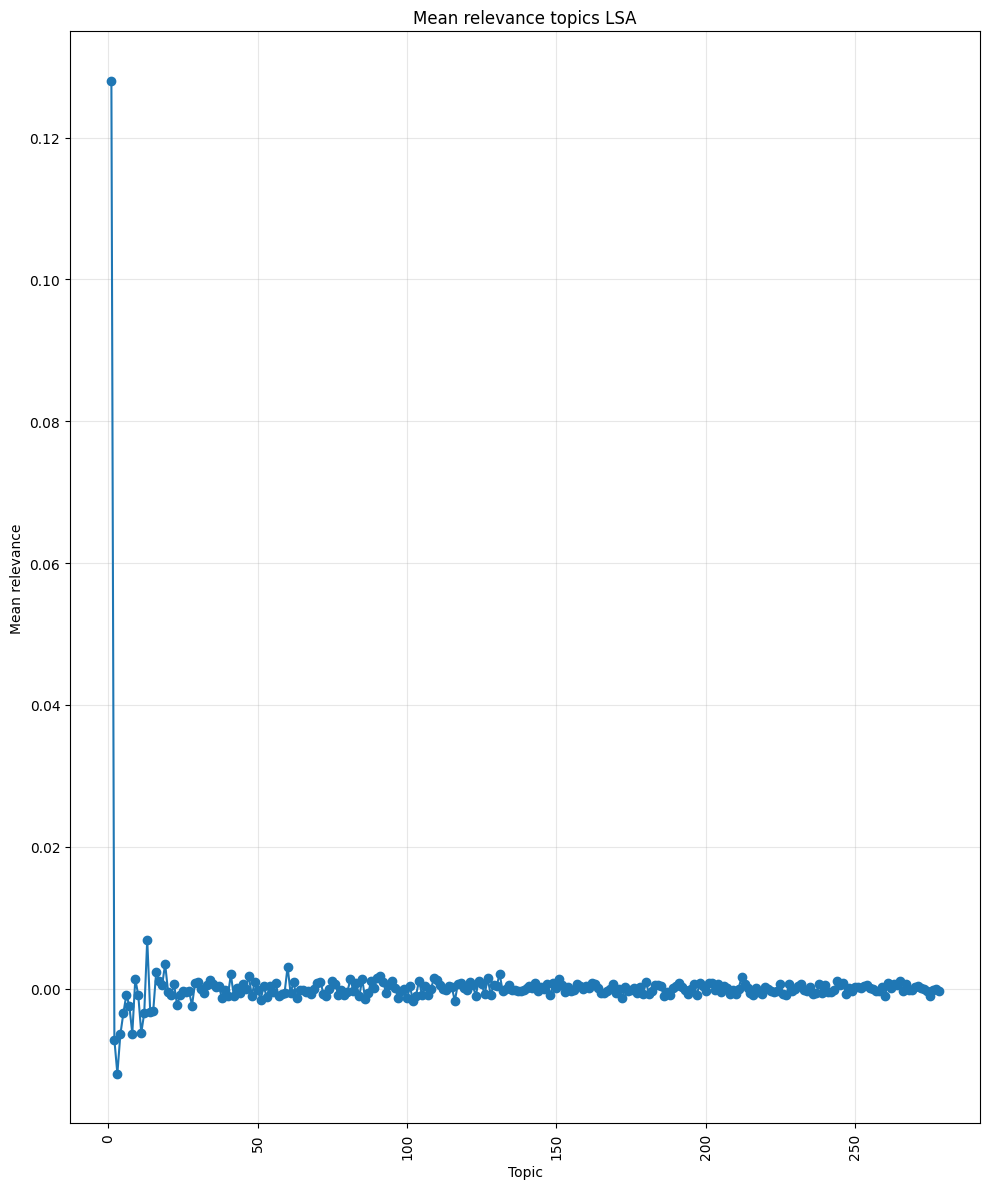

In [130]:
import_dict = {
    'Topico': [],
    'Importancia': []
}

for topic in topic_by_label.columns:
    import_dict['Topico'].append(topic)
    import_dict['Importancia'].append(topic_by_label[topic].mean())
        
#plotear importancia media
plt.figure(figsize=(10, 12))
aux_xlabel = [i for i in range(1,len(import_dict['Topico'])+1)]
plt.plot(aux_xlabel, import_dict['Importancia'], marker='o')

plt.title('Mean relevance topics LSA')
plt.xlabel('Topic')
plt.ylabel('Mean relevance')
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.4.3 Inspección de topicos para algunos ODS

In [ ]:
def inspect_topic_by_class(X_lsa, documents, labels, topic_idx, class_label, n=5):
    documents = np.asarray(documents)
    labels = np.asarray(labels)

    mask = labels == class_label

    class_indices = np.where(mask)[0]

    scores = X_lsa[class_indices, topic_idx]

    top_order = np.argsort(scores)[-n:][::-1]

    results = []

    for order in top_order:

        idx = class_indices[order]

        results.append({
            "document_index": idx,
            "label": labels[idx],
            "top_words_topic":topic_df['top_words'][topic_idx],
            "topic_score": X_lsa[idx, topic_idx],
            "document": documents[idx]
        })

    return pd.DataFrame(results)



#se inspeccionan 4 ODS (los dos mejores y los dos peores)

print('> Inspección topico 0 mejores ODS: 4 y 16: \n')

results = inspect_topic_by_class( X_lsa=X_lsa, documents=X_test, labels=y_test, topic_idx=0, class_label=4, n=3)
display(results)
results = inspect_topic_by_class( X_lsa=X_lsa, documents=X_test, labels=y_test, topic_idx=0, class_label=16, n=3)
display(results)

print('> Inspección topico 0 peores ODS: 10 y 8: \n')
results = inspect_topic_by_class( X_lsa=X_lsa, documents=X_test, labels=y_test, topic_idx=0, class_label=10, n=3)
display(results)
results = inspect_topic_by_class( X_lsa=X_lsa, documents=X_test, labels=y_test, topic_idx=0, class_label=8, n=3)
display(results)

> Inspección topico 0 mejores ODS: 4 y 16: 



,document_index,label,top_words_topic,topic_score,document
0,1254,4,"plazo, largo, cada, emisiones, zonas, informac...",0.078811,En ellos se basan las publicaciones anuales co...
1,402,4,"plazo, largo, cada, emisiones, zonas, informac...",0.078277,Examina cómo las desventajas pueden acumularse...
2,1815,4,"plazo, largo, cada, emisiones, zonas, informac...",0.074513,Algunos municipios también han introducido pol...


,document_index,label,top_words_topic,topic_score,document
0,986,16,"plazo, largo, cada, emisiones, zonas, informac...",0.080340,Este ensayo explica cómo la Corte Suprema de C...
1,277,16,"plazo, largo, cada, emisiones, zonas, informac...",0.070862,¿Por qué la mayoría de los países africanos es...
2,1871,16,"plazo, largo, cada, emisiones, zonas, informac...",0.070121,"En su jurisprudencia reciente, el Tribunal Eur..."


> Inspección topico 0 peores ODS: 10 y 8: 



,document_index,label,top_words_topic,topic_score,document
0,262,10,"plazo, largo, cada, emisiones, zonas, informac...",0.076633,La Ley de Promoción del Empleo incluye normas ...
1,1885,10,"plazo, largo, cada, emisiones, zonas, informac...",0.074090,"En su lugar, proponen un concepto de crecimien..."
2,995,10,"plazo, largo, cada, emisiones, zonas, informac...",0.070670,"A pesar de los ligeros avances, la pobreza ent..."


,document_index,label,top_words_topic,topic_score,document
0,674,8,"plazo, largo, cada, emisiones, zonas, informac...",0.093397,Una recesión o recesión económica puede result...
1,562,8,"plazo, largo, cada, emisiones, zonas, informac...",0.092542,"De lo contrario, el sistema australiano es bas..."
2,1158,8,"plazo, largo, cada, emisiones, zonas, informac...",0.080307,El actual plan a largo plazo (Rencana Pembangu...


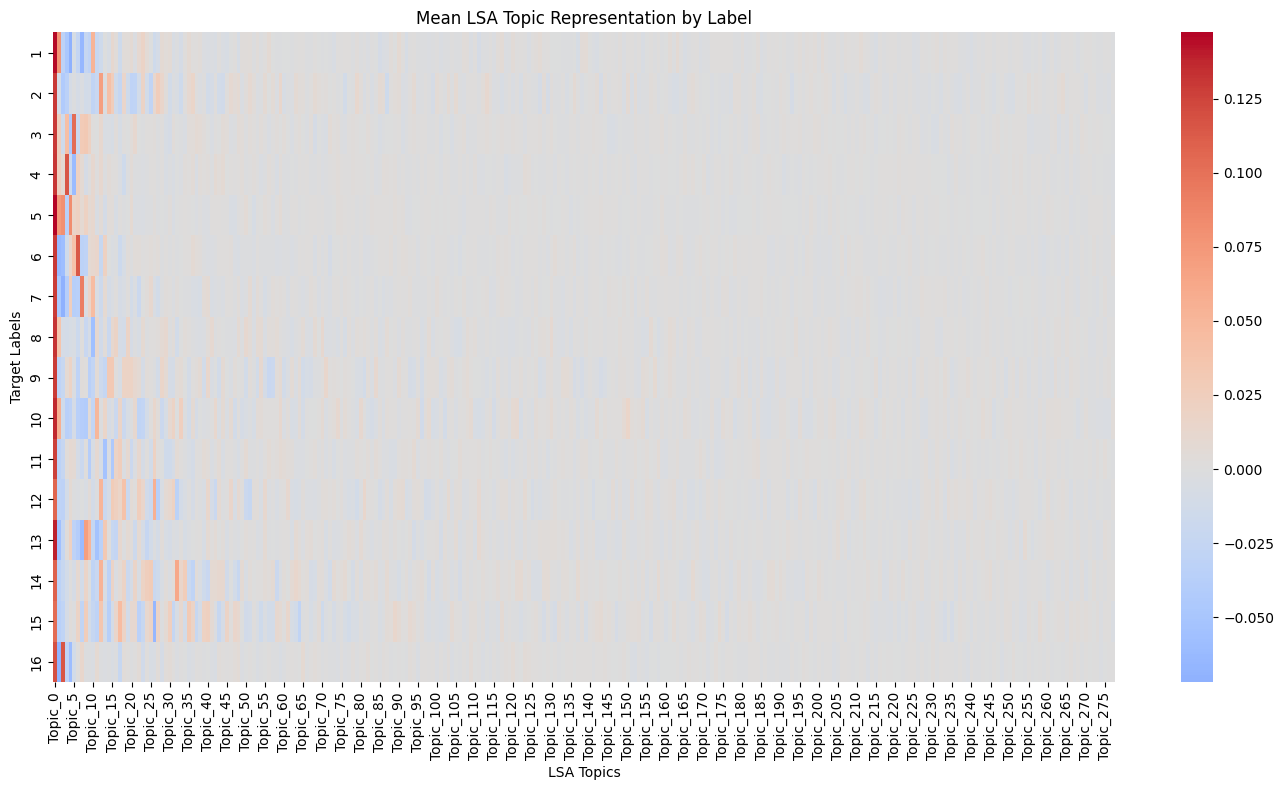

In [109]:
#grafica de la representacion media de los topicos LSA por cada ODS
plt.figure(figsize=(14, 8))

sns.heatmap( topic_by_label, cmap="coolwarm", center=0, annot=False)

plt.title("Mean LSA Topic Representation by Label")
plt.xlabel("LSA Topics")
plt.ylabel("Target Labels")
plt.tight_layout()
plt.show()

*Analisis*

* Conceptualmente, los componentes o topicos del analisis LSA son agrupaciones de palabras que representan un espacio semantico o tema concreto, pero tal, ahora bien, de acuerdo con los resultados vistos sobre la matriz construida una palabra no es exclusiva de un mismo topico, esta puede aparecer en multiples, lo cual permite inferir que es la combinacion en si de palabras la que define el topico, ahora bien, al interior de cada componente cada palabra posee un peso especifico.

* Al graficar el promedio de importancia de cada uno de los topicos para los ODS, se observa como las primeras componentes tienen un valor mas alto que las ultimas, esto puede ser un buen criterio para acotar el numero de componentes a usar en caso que se quiera reducir la dimensionalidad del modelo.

* El mapa de calor complementa la conclusión anterior, desagregando por cada uno de los ODS y topicos; sin embargo, en la medida que las primeras componentes suelen ser comunes para todas las clases, el peso de decision se traslada entonces a las primeras componentes que aporten verdadera varianza respecto a los puntajes asignados para cada documento.


In [144]:
#exportar mejor modelo
joblib.dump(best_estimator, "ods_classifier.pkl") 

['ods_classifier.pkl']

In [146]:
best_estimator.named_steps.keys()

dict_keys(['vectorizador', 'lsa', 'clasificador'])